# Futures MA Loopback Grid Search (CSV)

This notebook replicates the MA window grid-search workflow, but loads **futures price data from a CSV** (continuous series recommended).

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


In [24]:
# =========================
# Config
# =========================
CSV_PATH   = "../prices/GC.csv"   # <-- set this
DATE_COL   = "Date"
PRICE_COL  = "Close"            # or "Adj Close" if present
DATE_FMT   = "%d %b %Y"         # e.g., '23 Apr 1993' ; set None to auto-parse

# Strategy grid
ma_range   = range(10, 301, 10) # 20..300 step 10

# Execution choice:
# - "close_close": signal on close, apply same-day close-to-close (optimistic)
# - "open_open":   signal on close, execute next open (recommended if Open exists)
EXEC_MODE  = "open_open"


In [25]:
# =========================
# Data load (CSV -> Series)
# =========================
df = pd.read_csv(CSV_PATH)

# Parse dates
if DATE_FMT is None:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
else:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], format=DATE_FMT, errors="coerce")

df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).set_index(DATE_COL)

# Coerce numeric
for c in df.columns:
    if c != DATE_COL:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if PRICE_COL not in df.columns:
    raise ValueError(f"Missing PRICE_COL='{PRICE_COL}'. Available: {list(df.columns)}")

px = df[PRICE_COL].dropna().sort_index()

# Returns for backtest
if EXEC_MODE == "open_open":
    if "Open" not in df.columns:
        raise ValueError("EXEC_MODE='open_open' requires an 'Open' column in the CSV.")
    ret = df["Open"].pct_change().fillna(0.0)
else:
    # close-to-close
    px_ffill = px.ffill()
    ret = px_ffill.pct_change(fill_method=None).fillna(0.0)

display(df.head())
print(f"Rows: {len(df):,} | Start: {df.index.min().date()} | End: {df.index.max().date()}")

,Open,High,Low,Close,Volume,OpenInterest
Date,,,,,,
2010-09-10,1245.4,1251.8,1237.9,1247.4,2.2,0.0
2010-09-13,1247.9,1250.1,1242.3,1246.4,-1.0,0.0
2010-09-14,1245.2,1275.9,1245.2,1269.8,23.4,0.0
2010-09-15,1269.5,1273.0,1264.4,1269.1,-0.7,0.0
2010-09-16,1269.2,1279.2,1266.1,1276.3,7.2,0.0


Rows: 3,920 | Start: 2010-09-10 | End: 2026-01-30


In [26]:
# =========================
# Helpers (scalar KPIs)
# =========================
def kpi_from_equity(eq: pd.Series):
    eq = eq.dropna()
    if eq.empty or len(eq) < 2:
        return np.nan, np.nan, np.nan

    r = eq.pct_change().dropna()
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = (eq.iloc[-1] / eq.iloc[0])**(1/yrs) - 1 if yrs > 0 else np.nan

    vol = float(r.std(ddof=0)) * np.sqrt(252)
    sharpe = float((r.mean() * 252) / vol) if vol > 0 else np.nan

    mdd = float((eq / eq.cummax() - 1).min())
    return float(cagr), sharpe, abs(mdd)


In [27]:
# =========================
# Backtest each MA (no look-ahead)
# =========================
rows = []
for L in ma_range:
    ma = px.rolling(L).mean().shift(1)
    sig = (px > ma).astype(int)

    if EXEC_MODE == "open_open":
        # signal at close, position applies next open-to-open return
        sig_exec = sig.shift(1).reindex(ret.index).fillna(0.0)
        daily_ret = (ret * sig_exec).fillna(0.0)
    else:
        # close-to-close with 1-day lag on signal
        sig_exec = sig.shift(1).fillna(0.0)
        daily_ret = (ret.reindex(sig_exec.index).fillna(0.0) * sig_exec).fillna(0.0)

    equity = (1 + daily_ret).cumprod()
    if not equity.empty:
        equity.iloc[0] = 1.0

    cagr, sharpe, mdd = kpi_from_equity(equity)
    rows.append((L, cagr, sharpe, mdd))

res = pd.DataFrame(rows, columns=["MA_Length", "CAGR", "Sharpe", "MaxDD"]).set_index("MA_Length")

best_ma_length = res["Sharpe"].idxmax()
display(res.sort_values("Sharpe", ascending=False).head(10))

print("Best MA Length by Sharpe:", best_ma_length)

,CAGR,Sharpe,MaxDD
MA_Length,,,
10,0.633948,4.430037,0.046093
20,0.457774,3.281137,0.078621
30,0.379707,2.739476,0.097964
40,0.349755,2.525507,0.098719
50,0.285066,2.088581,0.098719
60,0.271758,2.009454,0.098719
70,0.260658,1.921487,0.098719
80,0.249557,1.841458,0.098719
90,0.235695,1.742528,0.130303


Best MA Length by Sharpe: 10


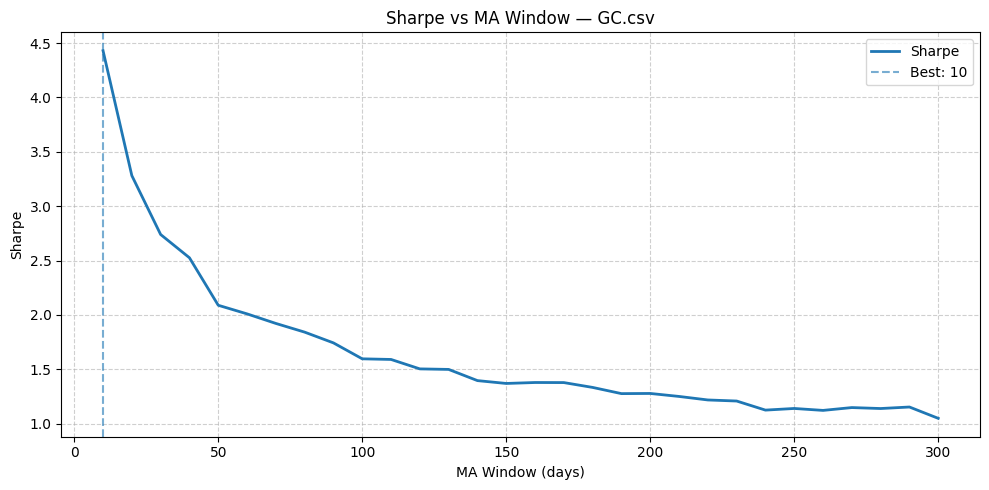

In [28]:
# =========================
# Sharpe vs MA Window
# =========================
plt.figure(figsize=(10, 5))
plt.plot(res.index, res["Sharpe"], linewidth=2, label="Sharpe")
plt.axvline(best_ma_length, linestyle="--", alpha=0.6, label=f"Best: {best_ma_length}")
plt.title(f"Sharpe vs MA Window — {os.path.basename(CSV_PATH)}")
plt.xlabel("MA Window (days)")
plt.ylabel("Sharpe")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


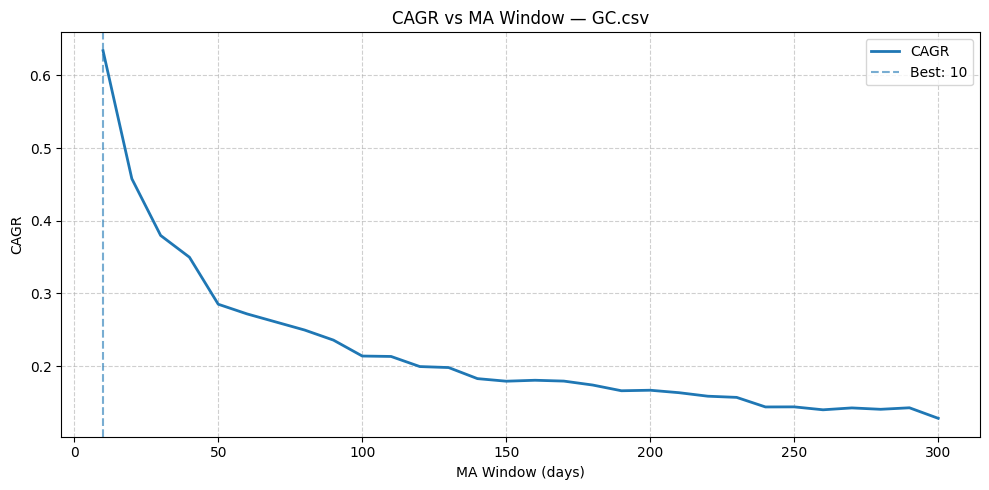

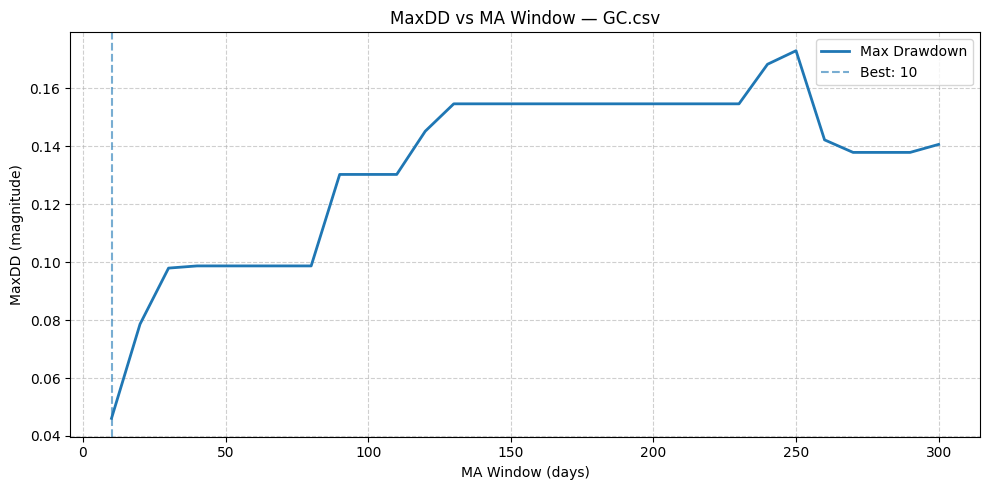

In [29]:
# =========================
# CAGR vs MA Window
# =========================
plt.figure(figsize=(10, 5))
plt.plot(res.index, res["CAGR"], linewidth=2, label="CAGR")
plt.axvline(best_ma_length, linestyle="--", alpha=0.6, label=f"Best: {best_ma_length}")
plt.title(f"CAGR vs MA Window — {os.path.basename(CSV_PATH)}")
plt.xlabel("MA Window (days)")
plt.ylabel("CAGR")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# Max Drawdown vs MA Window
# =========================
plt.figure(figsize=(10, 5))
plt.plot(res.index, res["MaxDD"], linewidth=2, label="Max Drawdown")
plt.axvline(best_ma_length, linestyle="--", alpha=0.6, label=f"Best: {best_ma_length}")
plt.title(f"MaxDD vs MA Window — {os.path.basename(CSV_PATH)}")
plt.xlabel("MA Window (days)")
plt.ylabel("MaxDD (magnitude)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


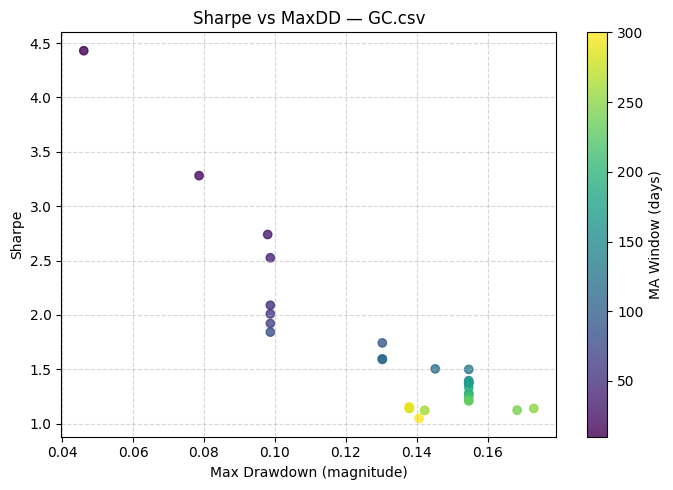

In [30]:
# =========================
# Sharpe vs MaxDD Scatter
# =========================
plt.figure(figsize=(7, 5))
plt.scatter(res["MaxDD"], res["Sharpe"], c=res.index, alpha=0.8)
plt.xlabel("Max Drawdown (magnitude)")
plt.ylabel("Sharpe")
plt.title(f"Sharpe vs MaxDD — {os.path.basename(CSV_PATH)}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.colorbar(label="MA Window (days)")
plt.tight_layout()
plt.show()


In [31]:
print("\nTop 5 MA windows by Sharpe:")
print(res.sort_values("Sharpe", ascending=False).head())



Top 5 MA windows by Sharpe:
               CAGR    Sharpe     MaxDD
MA_Length                              
10         0.633948  4.430037  0.046093
20         0.457774  3.281137  0.078621
30         0.379707  2.739476  0.097964
40         0.349755  2.525507  0.098719
50         0.285066  2.088581  0.098719
